In [ ]:
# Logistic Regression Example
# Predict whether a breast tumor is Malignant (0) or Benign (1)

# Step 1: Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Step 2: Load the dataset
data = load_breast_cancer()

X = data.data      # Input features
y = data.target    # Target labels (0 = malignant, 1 = benign)

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 4: Create and train the Logistic Regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)

# Step 6: Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------
# Evaluation Metrics
# ---------------------------------------------------

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

# ---------------------------------------------------
# Example prediction
# ---------------------------------------------------

print("\nExample Prediction")
print("------------------")
print("Predicted Class:", y_pred[0])
print("Probability of Benign:", y_prob[0])

if y_prob[0] >= 0.5:
    print("Model predicts the tumor is BENIGN.")
else:
    print("Model predicts the tumor is MALIGNANT.")

Accuracy:
0.956140350877193

Confusion Matrix:
[[39  4]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


ROC-AUC Score:
0.9977071732721913

Example Prediction
------------------
Predicted Class: 1
Probability of Benign: 0.8765215611402285
Model predicts the tumor is BENIGN.


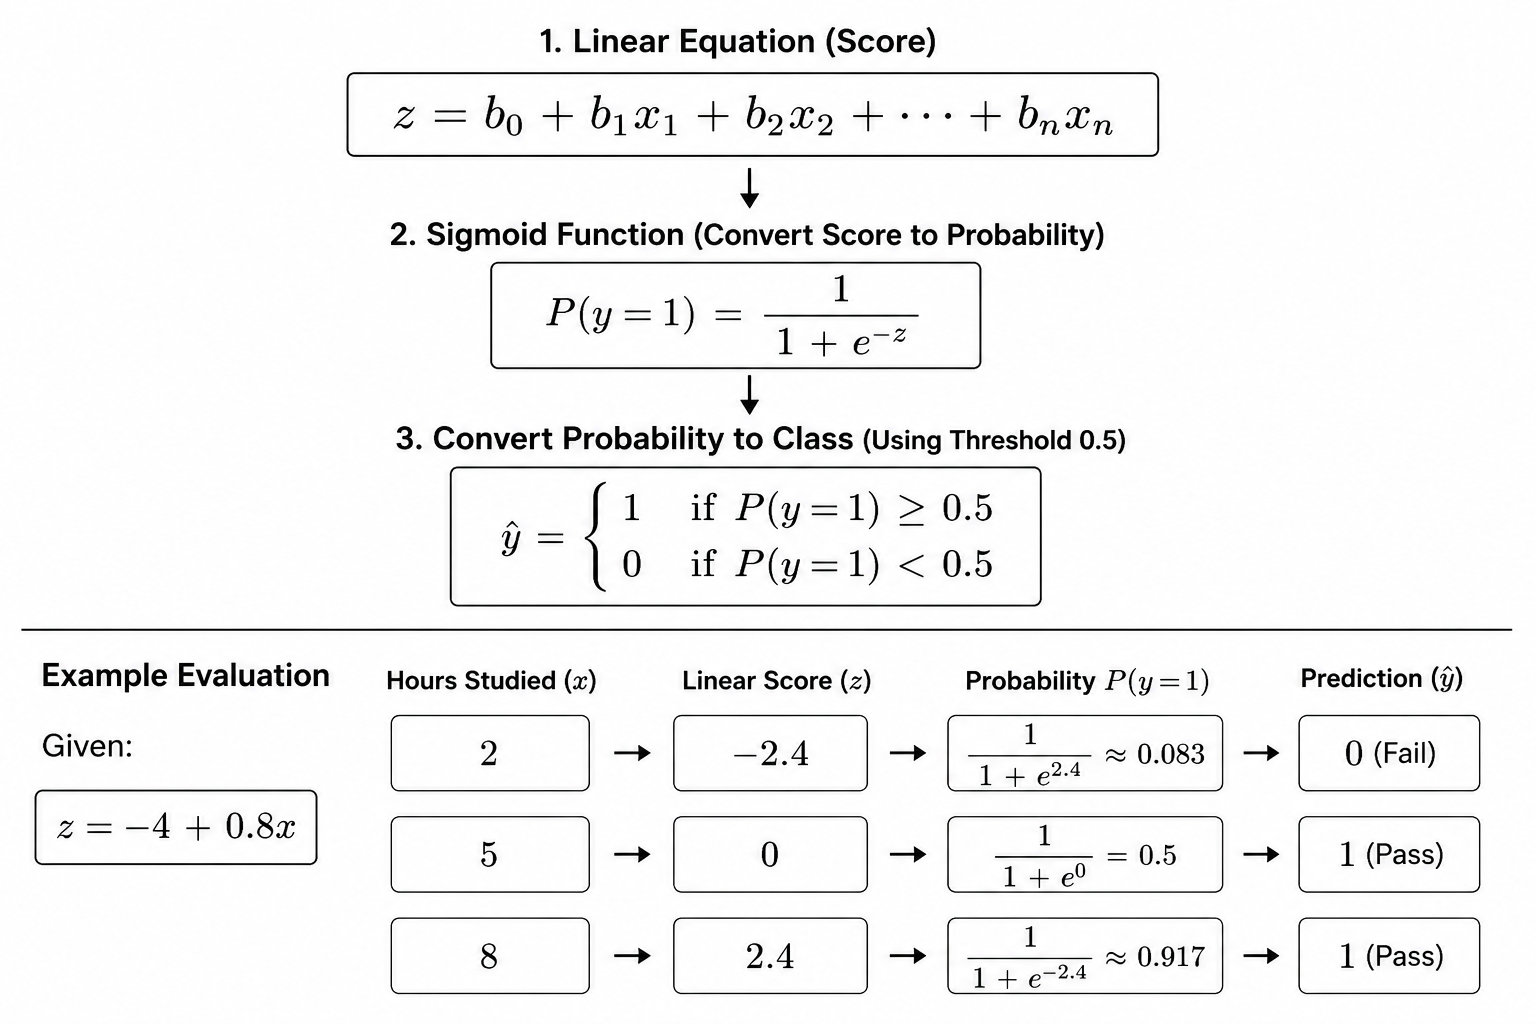

In [ ]:
# ============================================================
# Evaluation Metrics Explained
# ============================================================

# 1. Accuracy
# ----------------
# Accuracy tells us how many predictions the model got correct.
#
# Formula:
# Accuracy = (Correct Predictions) / (Total Predictions)
#
# Example:
# If the model predicts 96 out of 100 samples correctly,
# then Accuracy = 96 / 100 = 96%.
#
# Use accuracy when the classes are fairly balanced.

# 2. Confusion Matrix
# --------------------
# A confusion matrix summarizes the prediction results.
#
#                  Predicted
#                Malignant   Benign
# Actual
# Malignant          TN         FP
# Benign             FN         TP
#
# TN (True Negative):
#   Malignant tumor correctly predicted as Malignant.
#
# TP (True Positive):
#   Benign tumor correctly predicted as Benign.
#
# FP (False Positive):
#   Malignant tumor incorrectly predicted as Benign.
#
# FN (False Negative):
#   Benign tumor incorrectly predicted as Malignant.
#
# The confusion matrix helps identify the types of mistakes
# the model is making instead of only looking at overall accuracy.

# 3. Precision
# -------------
# Precision answers:
# "Of all samples predicted as Positive (Benign),
#  how many were actually Positive?"
#
# Formula:
# Precision = TP / (TP + FP)
#
# High precision means there are few False Positives.

# 4. Recall (Sensitivity)
# ------------------------
# Recall answers:
# "Of all actual Positive (Benign) samples,
#  how many did the model correctly identify?"
#
# Formula:
# Recall = TP / (TP + FN)
#
# High recall means there are few False Negatives.

# 5. F1-Score
# ------------
# F1-score combines Precision and Recall into one metric.
#
# Formula:
# F1 = 2 * (Precision * Recall) / (Precision + Recall)
#
# It is useful when you want a balance between
# Precision and Recall, especially for imbalanced datasets.

# 6. ROC-AUC Score
# -----------------Receiver Operating Characteristic (ROC) AUC (Area Under the Curve)
# ROC-AUC measures how well the model separates the two classes
# across all possible classification thresholds.
#
# Interpretation:
# AUC = 1.0  -> Perfect classifier
# AUC = 0.9  -> Excellent
# AUC = 0.8  -> Good
# AUC = 0.7  -> Fair
# AUC = 0.5  -> No better than random guessing
#
# The closer the ROC-AUC score is to 1, the better the model is
# at distinguishing between the two classes.
#
# ============================================================
# In simple words:
#
# Accuracy  -> "How often is the model correct?"
# Precision -> "When the model predicts Positive, how often is it right?"
# Recall    -> "How many actual Positive cases did the model find?"
# F1-Score  -> "Overall balance between Precision and Recall."
# ROC-AUC   -> "How well does the model separate the two classes?"
# ============================================================

In [ ]:
import seaborn as sns
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Keep only the columns we need
df = df[["survived", "pclass", "sex", "age", "fare"]]

# Remove rows with missing values
df = df.dropna()

# Convert sex to numbers
# male -> 0
# female -> 1
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# Features and target
X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "titanic_model.pkl")

print("Model trained and saved as titanic_model.pkl")

Model trained and saved as titanic_model.pkl


In [ ]:
import joblib

model = joblib.load("titanic_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import numpy as np

print("=== Titanic Survival Predictor ===")

pclass = int(input("Passenger Class (1, 2, or 3): "))

sex_input = input("Sex (male/female): ").strip().lower()
sex = 0 if sex_input == "male" else 1

age = float(input("Age: "))

fare = float(input("Fare Paid: "))

sample = np.array([[pclass, sex, age, fare]])

# Predict class
prediction = model.predict(sample)[0]

# Predict probabilities
probability = model.predict_proba(sample)[0]

print("\nProbability of NOT Surviving: {:.2f}%".format(probability[0] * 100))
print("Probability of Surviving: {:.2f}%".format(probability[1] * 100))

if prediction == 1:
    print("\nPrediction: ✅ Survived")
else:
    print("\nPrediction: ❌ Did Not Survive")

=== Titanic Survival Predictor ===
Passenger Class (1, 2, or 3): 2
Sex (male/female): male
Age: 23
Fare Paid: 343

Probability of NOT Surviving: 68.32%
Probability of Surviving: 31.68%

Prediction: ❌ Did Not Survive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


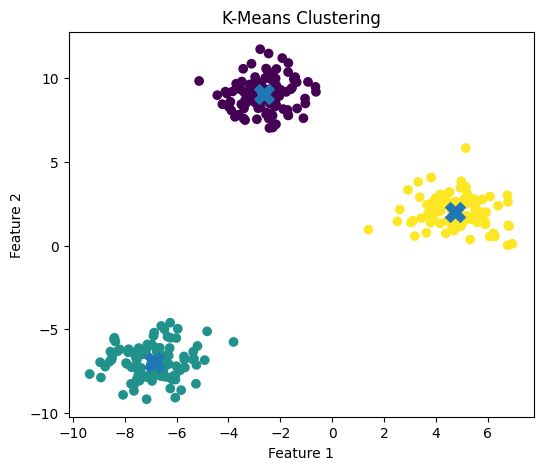

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create synthetic data
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42
)

# Train K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model
kmeans.fit(X)

# Get cluster labels
labels = kmeans.labels_

# Plot the clusters
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

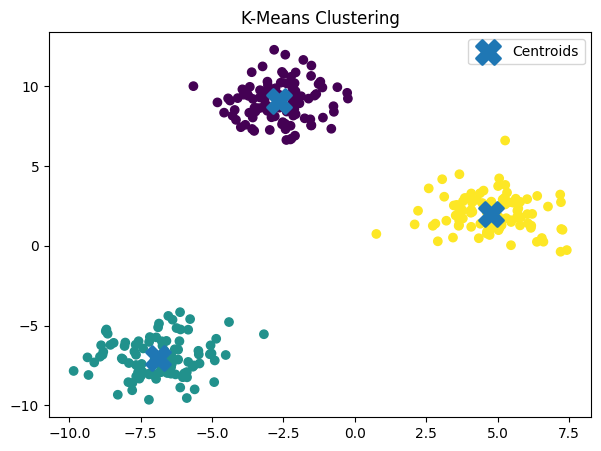

Final Centroids:
[[-2.65803969  9.04942651]
 [-6.88472071 -7.00475906]
 [ 4.76854828  2.01807919]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create synthetic data
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

# Train K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    max_iter=300
)

kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_

# Plot data points
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=300,
    linewidths=2,
    label="Centroids"
)

plt.legend()
plt.title("K-Means Clustering")
plt.show()

print("Final Centroids:")
print(kmeans.cluster_centers_)

In [ ]:
print("Number of iterations until convergence:", kmeans.n_iter_)

print("""
Interpretation:
- K-Means repeatedly updates the centroid positions.
- After each update, every point is reassigned to its nearest centroid.
- When the centroids stop changing (or change negligibly),
  the algorithm has converged and stops.
""")

Number of iterations until convergence: 2

Interpretation:
- K-Means repeatedly updates the centroid positions.
- After each update, every point is reassigned to its nearest centroid.
- When the centroids stop changing (or change negligibly),
  the algorithm has converged and stops.



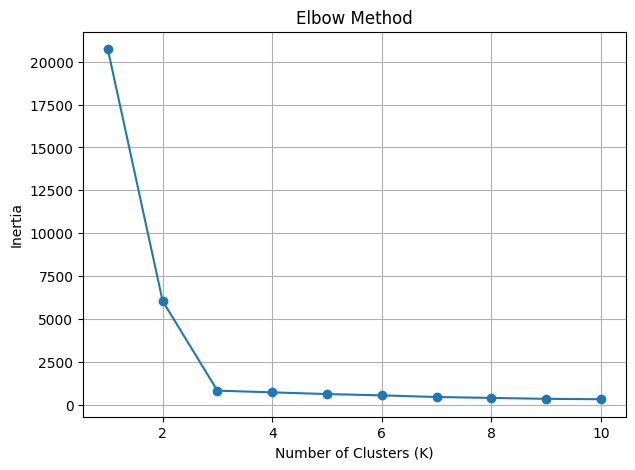

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

# Try different K values
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

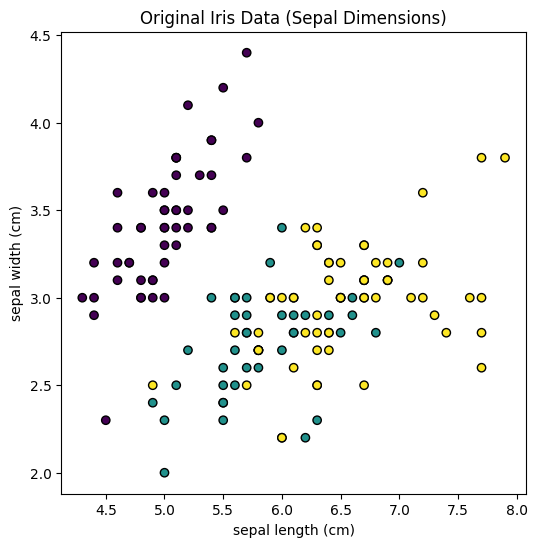

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import load_iris

ds = load_iris()

# Extract the features (X contains 4 columns: sepal length/width, petal length/width)
X = ds['data']

# Set up the visualization
plt.figure(figsize=(6, 6))

# Plot the first two features: Sepal Length vs Sepal Width
plt.scatter(X[:, 0], X[:, 1], c=ds['target'], cmap='viridis', edgecolor='k')

plt.xlabel(ds['feature_names'][0])  # Sepal length (cm)
plt.ylabel(ds['feature_names'][1])  # Sepal width (cm)
plt.title("Original Iris Data (Sepal Dimensions)")
plt.show()



In [2]:
from sklearn.cluster import DBSCAN

# eps = neighborhood radius
# min_samples = minimum points required to form a dense region
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

labels = dbscan.fit_predict(X)

print("Cluster labels:")
print(labels)

Cluster labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


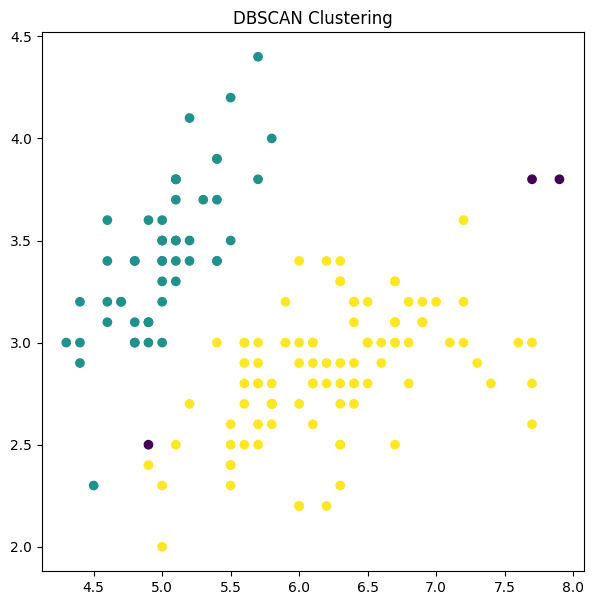

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels
)

plt.title("DBSCAN Clustering")

plt.show()

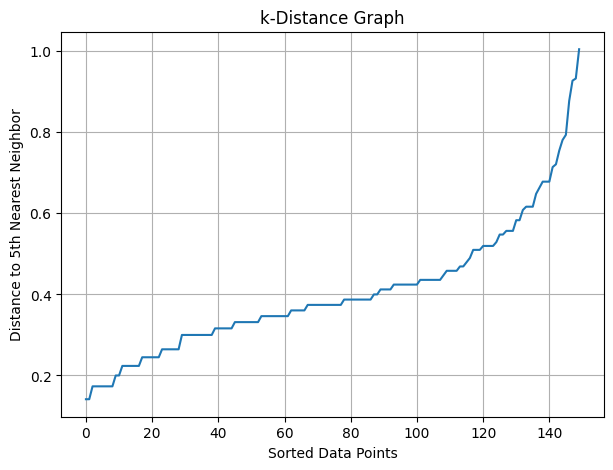

In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X)

distances, indices = neighbors.kneighbors(X)

# Distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,5))
plt.plot(k_distances)
plt.xlabel("Sorted Data Points")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("k-Distance Graph")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 3
Number of noise points: 3


In [5]:
# ============================
# Simple Deep Neural Network (DNN)
# ============================

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense

# ----------------------------
# Load Dataset
# ----------------------------
iris = load_iris()

X = iris.data          # Features
y = iris.target        # Labels (0, 1, 2)

# ----------------------------
# Split Dataset
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Feature Scaling
# ----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------
# Build Deep Neural Network
# ----------------------------
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(4,)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(3, activation='softmax'))

# ----------------------------
# Compile Model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# Train Model
# ----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# ----------------------------
# Evaluate Model
# ----------------------------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nFinal Test Loss :", loss)
print("Final Test Accuracy :", accuracy)

# ----------------------------
# Save Model
# ----------------------------
model.save("iris_dnn_model.h5")
print("\nModel saved as iris_dnn_model.h5")

# ----------------------------
# Load Model
# ----------------------------
loaded_model = load_model("iris_dnn_model.h5")
print("Model loaded successfully!")

# ----------------------------
# Predict on New Input
# ----------------------------
# Example:
# [sepal_length, sepal_width, petal_length, petal_width]
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Apply same scaling
new_sample = scaler.transform(new_sample)

prediction = loaded_model.predict(new_sample)

predicted_class = np.argmax(prediction)

print("\nPrediction Probabilities:")
print(prediction)

print("Predicted Class:", predicted_class)
print("Predicted Flower:", iris.target_names[predicted_class])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5104 - loss: 0.9750 - val_accuracy: 0.6667 - val_loss: 0.9680
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7708 - loss: 0.8222 - val_accuracy: 0.7083 - val_loss: 0.8608
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8438 - loss: 0.7068 - val_accuracy: 0.8750 - val_loss: 0.7798
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8646 - loss: 0.6184 - val_accuracy: 0.9167 - val_loss: 0.6862
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.5383 - val_accuracy: 0.8750 - val_loss: 0.5813
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8229 - loss: 0.4710 - val_accuracy: 0.8750 - val_loss: 0.4981
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8229 - loss: 0.4187 - val_accuracy: 0.8750 - val_loss: 0.4405
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8438 - loss: 0.3729 - val_accuracy: 0.9167 - val_loss


Final Test Loss : 0.025741802528500557
Final Test Accuracy : 1.0

Model saved as iris_dnn_model.h5
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Prediction Probabilities:
[[9.999255e-01 7.443851e-05 7.642403e-08]]
Predicted Class: 0
Predicted Flower: setosa
